In [1]:
import nltk
import csv
import numpy as np
import codecs

In [2]:
def load_training_data():
    with open("data/Spam.csv", 'r', encoding="UTF-8", errors="ignore") as csvfile:
        reader = csv.reader(csvfile, delimiter=',', quotechar='"')
        total_list = []
        X = []
        Y = []

        for row in reader:
            # print(row)
            if row[1] == "neutral":
                continue
            else:
                # print(row[0])
                X.append(row[0])  # Message
                Y.append(row[1])  # Class
                total_list.append(row)

        classes = np.unique(Y)

        for each_class in classes:
            print(each_class)

        print((('-' * 33) + "\n") + "Length of Total List: ", len(total_list))

    return (total_list)


spam_ham = load_training_data()

Class
ham
spam
---------------------------------
Length of Total List:  5573


In [3]:
messages = []

for (words, category) in spam_ham:
    words_filtered = [e.lower() for e in words.split() if len(e) >= 3]
    messages.append((words_filtered, category))


def get_words_in_messages(messages):
    all_words = []

    for (words, category) in messages:
        all_words.extend(words)

    return all_words


def get_word_features(wordlist):
    wordlist = nltk.FreqDist(wordlist)
    word_features = wordlist.keys()

    return word_features


def extract_features(document):
    document_words = set(document)
    features = {}

    for word in word_features:
        features["Contains: (%s)" % word] = (word in document_words)

    return features


word_features = get_word_features(get_words_in_messages(messages))
training_set = nltk.classify.apply_features(extract_features, messages)
classifier = nltk.NaiveBayesClassifier.train(training_set)

In [4]:
print("RESULTS".center(90, '_') + "\n" +
      "Accuracy:" + "\t" + f"{(nltk.classify.util.accuracy(classifier, training_set)) * 100}%", end="\n\n")
classifier.show_most_informative_features(20)

print('_' * 90)

_________________________________________RESULTS__________________________________________
Accuracy:	99.1925354387224%

Most Informative Features
         Contains: (100) = True             spam : ham    =    161.3 : 1.0
      Contains: (latest) = True             spam : ham    =    148.4 : 1.0
     Contains: (message) = True            Class : ham    =     96.5 : 1.0
        Contains: (2000) = True             spam : ham    =     92.5 : 1.0
       Contains: (nokia) = True             spam : ham    =     91.2 : 1.0
       Contains: (await) = True             spam : ham    =     83.9 : 1.0
        Contains: (now!) = True             spam : ham    =     82.7 : 1.0
     Contains: (service) = True             spam : ham    =     69.5 : 1.0
       Contains: (video) = True             spam : ham    =     68.4 : 1.0
         Contains: (txt) = True             spam : ham    =     66.8 : 1.0
        Contains: (code) = True             spam : ham    =     66.7 : 1.0
    Contains: (selected) = Tr

In [5]:
def load_test_data():
    test_messages = []
    test = codecs.open("data/Spamtest.txt", 'r', "UTF-8")

    for each_value in test:
        test_messages.append(each_value)

    return test_messages

In [6]:
run_messages = load_test_data()  # Load test file containing messages only i.e. without lab...
spam_count = 0
ham_count = 0

for each_messages in run_messages:
    values = classifier.classify(extract_features(each_messages.split()))

    # Un-comment below, to dislay texts:
    print("Message: ", each_messages, " : ", values)

    if values == "ham":
        ham_count = ham_count + 1
    else:
        spam_count = spam_count + 1

        print('-' * 147)
        print("Spam Count: %s" % spam_count)
        print('-' * 147)
        print("Ham Count: %s" % ham_count)
        print('-' * 147)

C:\Users\hp\AppData\Local\Temp\ipykernel_3520\1751773701.py:3: DeprecationWarning: codecs.open() is deprecated. Use open() instead.
  test = codecs.open("data/Spamtest.txt", 'r', "UTF-8")


Message:  Okay name ur price as long as its legal! Wen can I pick them up? Y u ave x ams xx
  :  ham
Message:  I'm still looking for a car to buy. And have not gone 4the driving test yet.
  :  ham
Message:  As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
  :  ham
Message:  wow. You're right! I didn't mean to do that. I guess once i gave up on boston men and changed my search location to nyc, something changed. Cuz on my signin page it still says boston.
  :  ham
Message:  Umma my life and vava umma love you lot dear
  :  ham
Message:  Thanks a lot for your wishes on my birthday. Thanks you for making my birthday truly memorable.
  :  ham
Message:  Aight, I'll hit you up when I get some cash
  :  ham
Message:  How would my ip address test that considering my computer isn't a minecraft server
  :  ham
Message:  I know! Grumpy old people. My mom was like you better not be lying

In [7]:
import string
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import (SVR, SVC)
from sklearn.tree import (DecisionTreeRegressor, DecisionTreeClassifier)
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from matplotlib import style
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [8]:
spam_dataset = pd.read_csv("data/spam.csv", encoding="latin-1")

print("First 10 Elements of 'spam.csv':")
print('-' * 63)
spam_dataset[:10]

First 10 Elements of 'spam.csv':
---------------------------------------------------------------


,Message,Class
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham
5,FreeMsg Hey there darling it's been 3 week's n...,spam
6,Even my brother is not like to speak with me. ...,ham
7,As per your request 'Melle Melle (Oru Minnamin...,ham
8,WINNER!! As a valued network customer you have...,spam
9,Had your mobile 11 months or more? U R entitle...,spam


In [9]:
print("Last 10 Elements of 'data/spam.csv':")
print('-' * 63)
spam_dataset[-10:]

Last 10 Elements of 'data/spam.csv':
---------------------------------------------------------------


,Message,Class
5562,Ok lor... Sony ericsson salesman... I ask shuh...,ham
5563,Ard 6 like dat lor.,ham
5564,Why don't you wait 'til at least wednesday to ...,ham
5565,Huh y lei...,ham
5566,REMINDER FROM O2: To get 2.50 pounds free call...,spam
5567,This is the 2nd time we have tried 2 contact u...,spam
5568,Will Ì_ b going to esplanade fr home?,ham
5569,"Pity, * was in mood for that. So...any other s...",ham
5570,The guy did some bitching but I acted like i'd...,ham
5571,Rofl. Its true to its name,ham


In [10]:
spam_dataset["Length"] = spam_dataset["Message"].apply(len)

print("First 10 Elements of 'spam.csv', with the 'Column: Length' included:")
print('-' * 73)
spam_dataset[:10]

First 10 Elements of 'spam.csv', with the 'Column: Length' included:
-------------------------------------------------------------------------


,Message,Class,Length
0,"Go until jurong point, crazy.. Available only ...",ham,111
1,Ok lar... Joking wif u oni...,ham,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,155
3,U dun say so early hor... U c already then say...,ham,49
4,"Nah I don't think he goes to usf, he lives aro...",ham,61
5,FreeMsg Hey there darling it's been 3 week's n...,spam,148
6,Even my brother is not like to speak with me. ...,ham,77
7,As per your request 'Melle Melle (Oru Minnamin...,ham,160
8,WINNER!! As a valued network customer you have...,spam,158
9,Had your mobile 11 months or more? U R entitle...,spam,154


In [11]:
print("Last 10 Elements of 'spam.csv', with the with 'Column: Length' included:")
print('-' * 77)
spam_dataset[-10:]

Last 10 Elements of 'spam.csv', with the with 'Column: Length' included:
-----------------------------------------------------------------------------


,Message,Class,Length
5562,Ok lor... Sony ericsson salesman... I ask shuh...,ham,96
5563,Ard 6 like dat lor.,ham,19
5564,Why don't you wait 'til at least wednesday to ...,ham,67
5565,Huh y lei...,ham,12
5566,REMINDER FROM O2: To get 2.50 pounds free call...,spam,147
5567,This is the 2nd time we have tried 2 contact u...,spam,161
5568,Will Ì_ b going to esplanade fr home?,ham,37
5569,"Pity, * was in mood for that. So...any other s...",ham,57
5570,The guy did some bitching but I acted like i'd...,ham,125
5571,Rofl. Its true to its name,ham,26


In [14]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Download the required NLTK data (only needs to be done once)
nltk.download('stopwords')

def preprocess(spam_messages):
    messages = spam_messages.translate(str.maketrans('', '', string.punctuation))
    messages = [word for word in messages.split() if word.lower() not in stopwords.words("english")]
    spam_words = ''

    print(messages)  # Un-comment to display texts...

    for message in messages:
        stemmer = SnowballStemmer("english")
        spam_words += (stemmer.stem(message)) + " "

    return spam_words

# Now your original code will work
text_features = spam_dataset["Message"].copy()
text_features = text_features.apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


['Go', 'jurong', 'point', 'crazy', 'Available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'Cine', 'got', 'amore', 'wat']
['Ok', 'lar', 'Joking', 'wif', 'u', 'oni']
['Free', 'entry', '2', 'wkly', 'comp', 'win', 'FA', 'Cup', 'final', 'tkts', '21st', 'May', '2005', 'Text', 'FA', '87121', 'receive', 'entry', 'questionstd', 'txt', 'rateTCs', 'apply', '08452810075over18s']
['U', 'dun', 'say', 'early', 'hor', 'U', 'c', 'already', 'say']
['Nah', 'dont', 'think', 'goes', 'usf', 'lives', 'around', 'though']
['FreeMsg', 'Hey', 'darling', '3', 'weeks', 'word', 'back', 'Id', 'like', 'fun', 'still', 'Tb', 'ok', 'XxX', 'std', 'chgs', 'send', 'å£150', 'rcv']
['Even', 'brother', 'like', 'speak', 'treat', 'like', 'aids', 'patent']
['per', 'request', 'Melle', 'Melle', 'Oru', 'Minnaminunginte', 'Nurungu', 'Vettam', 'set', 'callertune', 'Callers', 'Press', '9', 'copy', 'friends', 'Callertune']
['WINNER', 'valued', 'network', 'customer', 'selected', 'receivea', 'å£900', 'prize', 'reward', 'claim'

In [15]:
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(text_features)

In [16]:
print("First 10 Elements from the 'Dataset - spam.csv':")
print('-' * 63)
text_features[:10]

First 10 Elements from the 'Dataset - spam.csv':
---------------------------------------------------------------


0    go jurong point crazi avail bugi n great world...
1                               ok lar joke wif u oni 
2    free entri 2 wkli comp win fa cup final tkts 2...
3                 u dun say earli hor u c alreadi say 
4           nah dont think goe usf live around though 
5    freemsg hey darl 3 week word back id like fun ...
6       even brother like speak treat like aid patent 
7    per request mell mell oru minnaminungint nurun...
8    winner valu network custom select receivea å£9...
9    mobil 11 month u r entitl updat latest colour ...
Name: Message, dtype: str

In [17]:
print("Features from the 'Dataset - spam.csv':")
print('-' * 63)
print(features)

Features from the 'Dataset - spam.csv':
---------------------------------------------------------------
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 46982 stored elements and shape (5572, 8037)>
  Coords	Values
  (0, 3289)	0.14081218308843002
  (0, 4063)	0.3501112803835596
  (0, 5539)	0.23906338437276378
  (0, 2223)	0.2711370860940892
  (0, 1327)	0.2662313123328933
  (0, 1726)	0.29577542446330046
  (0, 3380)	0.19449555011263384
  (0, 7776)	0.2379272168522122
  (0, 4204)	0.29577542446330046
  (0, 1724)	0.33421906130459
  (0, 2006)	0.29577542446330046
  (0, 3342)	0.164475816719243
  (0, 1138)	0.3501112803835596
  (0, 7574)	0.19449555011263384
  (1, 5170)	0.2827396376113674
  (1, 4239)	0.42078899608869724
  (1, 4029)	0.47731294876998304
  (1, 7688)	0.44480400570972006
  (1, 5200)	0.5633086751818669
  (2, 3108)	0.1156013509460074
  (2, 2769)	0.35890157185696997
  (2, 7734)	0.1899683039634032
  (2, 2101)	0.19609614678919884
  (2, 7701)	0.145407091351942
  (2, 2886)	0.468331

In [18]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
spam_dataset["Class"] = label_encoder.fit_transform(spam_dataset["Class"])

print("First 10 Elements of 'spam.csv', with the 'Column - Class' included:")
print('-' * 73)
spam_dataset[:10]

First 10 Elements of 'spam.csv', with the 'Column - Class' included:
-------------------------------------------------------------------------


,Message,Class,Length
0,"Go until jurong point, crazy.. Available only ...",0,111
1,Ok lar... Joking wif u oni...,0,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,U dun say so early hor... U c already then say...,0,49
4,"Nah I don't think he goes to usf, he lives aro...",0,61
5,FreeMsg Hey there darling it's been 3 week's n...,1,148
6,Even my brother is not like to speak with me. ...,0,77
7,As per your request 'Melle Melle (Oru Minnamin...,0,160
8,WINNER!! As a valued network customer you have...,1,158
9,Had your mobile 11 months or more? U R entitle...,1,154


In [19]:
print("Last 10 Elements of 'spam.csv', with the 'Column - Class' included:")
print('-' * 73)
spam_dataset[-10:]

Last 10 Elements of 'spam.csv', with the 'Column - Class' included:
-------------------------------------------------------------------------


,Message,Class,Length
5562,Ok lor... Sony ericsson salesman... I ask shuh...,0,96
5563,Ard 6 like dat lor.,0,19
5564,Why don't you wait 'til at least wednesday to ...,0,67
5565,Huh y lei...,0,12
5566,REMINDER FROM O2: To get 2.50 pounds free call...,1,147
5567,This is the 2nd time we have tried 2 contact u...,1,161
5568,Will Ì_ b going to esplanade fr home?,0,37
5569,"Pity, * was in mood for that. So...any other s...",0,57
5570,The guy did some bitching but I acted like i'd...,0,125
5571,Rofl. Its true to its name,0,26


In [20]:
print("Value Counts for the 'Elements - ham and spam' in the 'Dataset - spam.csv':")
print('-' * 80)
spam_dataset["Class"].value_counts()

Value Counts for the 'Elements - ham and spam' in the 'Dataset - spam.csv':
--------------------------------------------------------------------------------


Class
0    4825
1     747
Name: count, dtype: int64

In [22]:
features_train, features_test, labels_train, \
    labels_test = train_test_split(features, spam_dataset["Class"], test_size=0.3, random_state=111)

In [23]:
dtr = DecisionTreeRegressor()

dtr.fit(features_train, labels_train)

dtr_prediction = dtr.predict(features_test)
dtr_accuracy_score = accuracy_score(labels_test, dtr_prediction.round()) * 100
dtr_precision_score = precision_score(labels_test, dtr_prediction.round(), average="weighted") * 100
dtr_recall_score = recall_score(labels_test, dtr_prediction.round(), average="weighted") * 100
dtr_f1_score = f1_score(labels_test, dtr_prediction.round(), average="weighted") * 100

print("Evaluation for Decision Tree Regressor".center(55, '_'))
print("Model Type:" + "\t", dtr)
print("Prediction:" + "\t", dtr_prediction.round())
print('-' * 55)

print("Accuracy Score:" + "\t", "{accuracy_score:.6f}%".format(accuracy_score=dtr_accuracy_score))
print("Precision Score:", "{precision_score:.6f}%".format(precision_score=dtr_precision_score))
print("Recall Score:" + "\t", "{recall_score:.6f}%".format(recall_score=dtr_recall_score))
print("F1-Score:" + "\t", "{f1_score:.6f}%".format(f1_score=dtr_f1_score))
print('-' * 55)

_________Evaluation for Decision Tree Regressor________
Model Type:	 DecisionTreeRegressor()
Prediction:	 [0. 0. 0. ... 0. 0. 0.]
-------------------------------------------------------
Accuracy Score:	 96.411483%
Precision Score: 96.367181%
Recall Score:	 96.411483%
F1-Score:	 96.384975%
-------------------------------------------------------


In [24]:
print("Confusion Matrix for Decision Tree Regressor - 'Labels Test' & 'Prediction':")
print('_' * 79)
print(confusion_matrix(labels_test, dtr_prediction.round()))

Confusion Matrix for Decision Tree Regressor - 'Labels Test' & 'Prediction':
_______________________________________________________________________________
[[1414   26]
 [  34  198]]


In [25]:
print("Classification Report for Decision Tree Regressor - 'Labels Test' & 'Prediction':")
print('_' * 83)
print(classification_report(labels_test, dtr_prediction.round()))

Classification Report for Decision Tree Regressor - 'Labels Test' & 'Prediction':
___________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1440
           1       0.88      0.85      0.87       232

    accuracy                           0.96      1672
   macro avg       0.93      0.92      0.92      1672
weighted avg       0.96      0.96      0.96      1672



In [26]:
rfr = RandomForestRegressor()

rfr.fit(features_train, labels_train)

rfr_prediction = rfr.predict(features_test)
rfr_accuracy_score = accuracy_score(labels_test, rfr_prediction.round()) * 100
rfr_precision_score = precision_score(labels_test, rfr_prediction.round(), average="weighted") * 100
rfr_recall_score = recall_score(labels_test, rfr_prediction.round(), average="weighted") * 100
rfr_f1_score = f1_score(labels_test, rfr_prediction.round(), average="weighted") * 100

print("Evaluation for Random Forest Regressor".center(60, '_'))
print("Model Type:" + "\t", rfr)
print("Prediction:" + "\t", rfr_prediction)
print('-' * 60)

print("Accuracy Score:" + "\t", "{accuracy_score:.6f}%".format(accuracy_score=rfr_accuracy_score))
print("Precision Score:", "{precision_score:.6f}%".format(precision_score=rfr_precision_score))
print("Recall Score:" + "\t", "{recall_score:.6f}%".format(recall_score=rfr_recall_score))
print("F1-Score:" + "\t", "{f1_score:.6f}%".format(f1_score=rfr_f1_score))
print('-' * 60)

___________Evaluation for Random Forest Regressor___________
Model Type:	 RandomForestRegressor()
Prediction:	 [0.   0.   0.   ... 0.   0.04 0.  ]
------------------------------------------------------------
Accuracy Score:	 96.531100%
Precision Score: 96.455849%
Recall Score:	 96.531100%
F1-Score:	 96.464934%
------------------------------------------------------------


In [28]:
print("Confusion Matrix for Random Forest Regressor - 'Labels Test' & 'Prediction':")
print('_' * 83)
print(confusion_matrix(labels_test, rfr_prediction.round()))

Confusion Matrix for Random Forest Regressor - 'Labels Test' & 'Prediction':
___________________________________________________________________________________
[[1421   19]
 [  39  193]]


In [29]:
print("Classification Report for Random Forest Regressor - 'Labels Test' & 'Prediction':")
print('_' * 85)
print(classification_report(labels_test, rfr_prediction.round()))

Classification Report for Random Forest Regressor - 'Labels Test' & 'Prediction':
_____________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1440
           1       0.91      0.83      0.87       232

    accuracy                           0.97      1672
   macro avg       0.94      0.91      0.92      1672
weighted avg       0.96      0.97      0.96      1672



In [30]:
svr = SVR()

svr.fit(features_train, labels_train)

svr_prediction = svr.predict(features_test)
svr_accuracy_score = accuracy_score(labels_test, svr_prediction.round()) * 100
svr_precision_score = precision_score(labels_test, svr_prediction.round(), average="weighted") * 100
svr_recall_score = recall_score(labels_test, svr_prediction.round(), average="weighted") * 100
svr_f1_score = f1_score(labels_test, svr_prediction.round(), average="weighted") * 100

print("Evaluation for Epsilon-Support Vector Regression".center(65, '_'))
print("Model Type:" + "\t", svr)
print("Prediction:" + "\t", svr_prediction.round())
print('-' * 65)

print("Accuracy Score:" + "\t", "{accuracy_score:.6f}%".format(accuracy_score=svr_accuracy_score))
print("Precision Score:", "{precision_score:.6f}%".format(precision_score=svr_precision_score))
print("Recall Score:" + "\t", "{recall_score:.6f}%".format(recall_score=svr_recall_score))
print("F1-Score:" + "\t", "{f1_score:.6f}%".format(f1_score=svr_f1_score))
print('-' * 65)

_________Evaluation for Epsilon-Support Vector Regression________
Model Type:	 SVR()
Prediction:	 [ 0. -0.  0. ...  0.  0.  0.]
-----------------------------------------------------------------
Accuracy Score:	 97.488038%
Precision Score: 97.541853%
Recall Score:	 97.488038%
F1-Score:	 97.386755%
-----------------------------------------------------------------


In [32]:
print("Confusion Matrix for Epsilon-Support Vector Regression (SVR) - 'Labels Test' & 'Prediction':")
print('_' * 90)
print(confusion_matrix(labels_test, svr_prediction.round()))  # Added missing closing parenthesis

Confusion Matrix for Epsilon-Support Vector Regression (SVR) - 'Labels Test' & 'Prediction':
__________________________________________________________________________________________
[[1439    1]
 [  41  191]]


In [33]:
print("Classification Report for Epsilon-Support Vector Regression (SVR) - 'Labels Test' & 'Prediction':")
print('_' * 95)
print(classification_report(labels_test, svr_prediction.round()))

Classification Report for Epsilon-Support Vector Regression (SVR) - 'Labels Test' & 'Prediction':
_______________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1440
           1       0.99      0.82      0.90       232

    accuracy                           0.97      1672
   macro avg       0.98      0.91      0.94      1672
weighted avg       0.98      0.97      0.97      1672



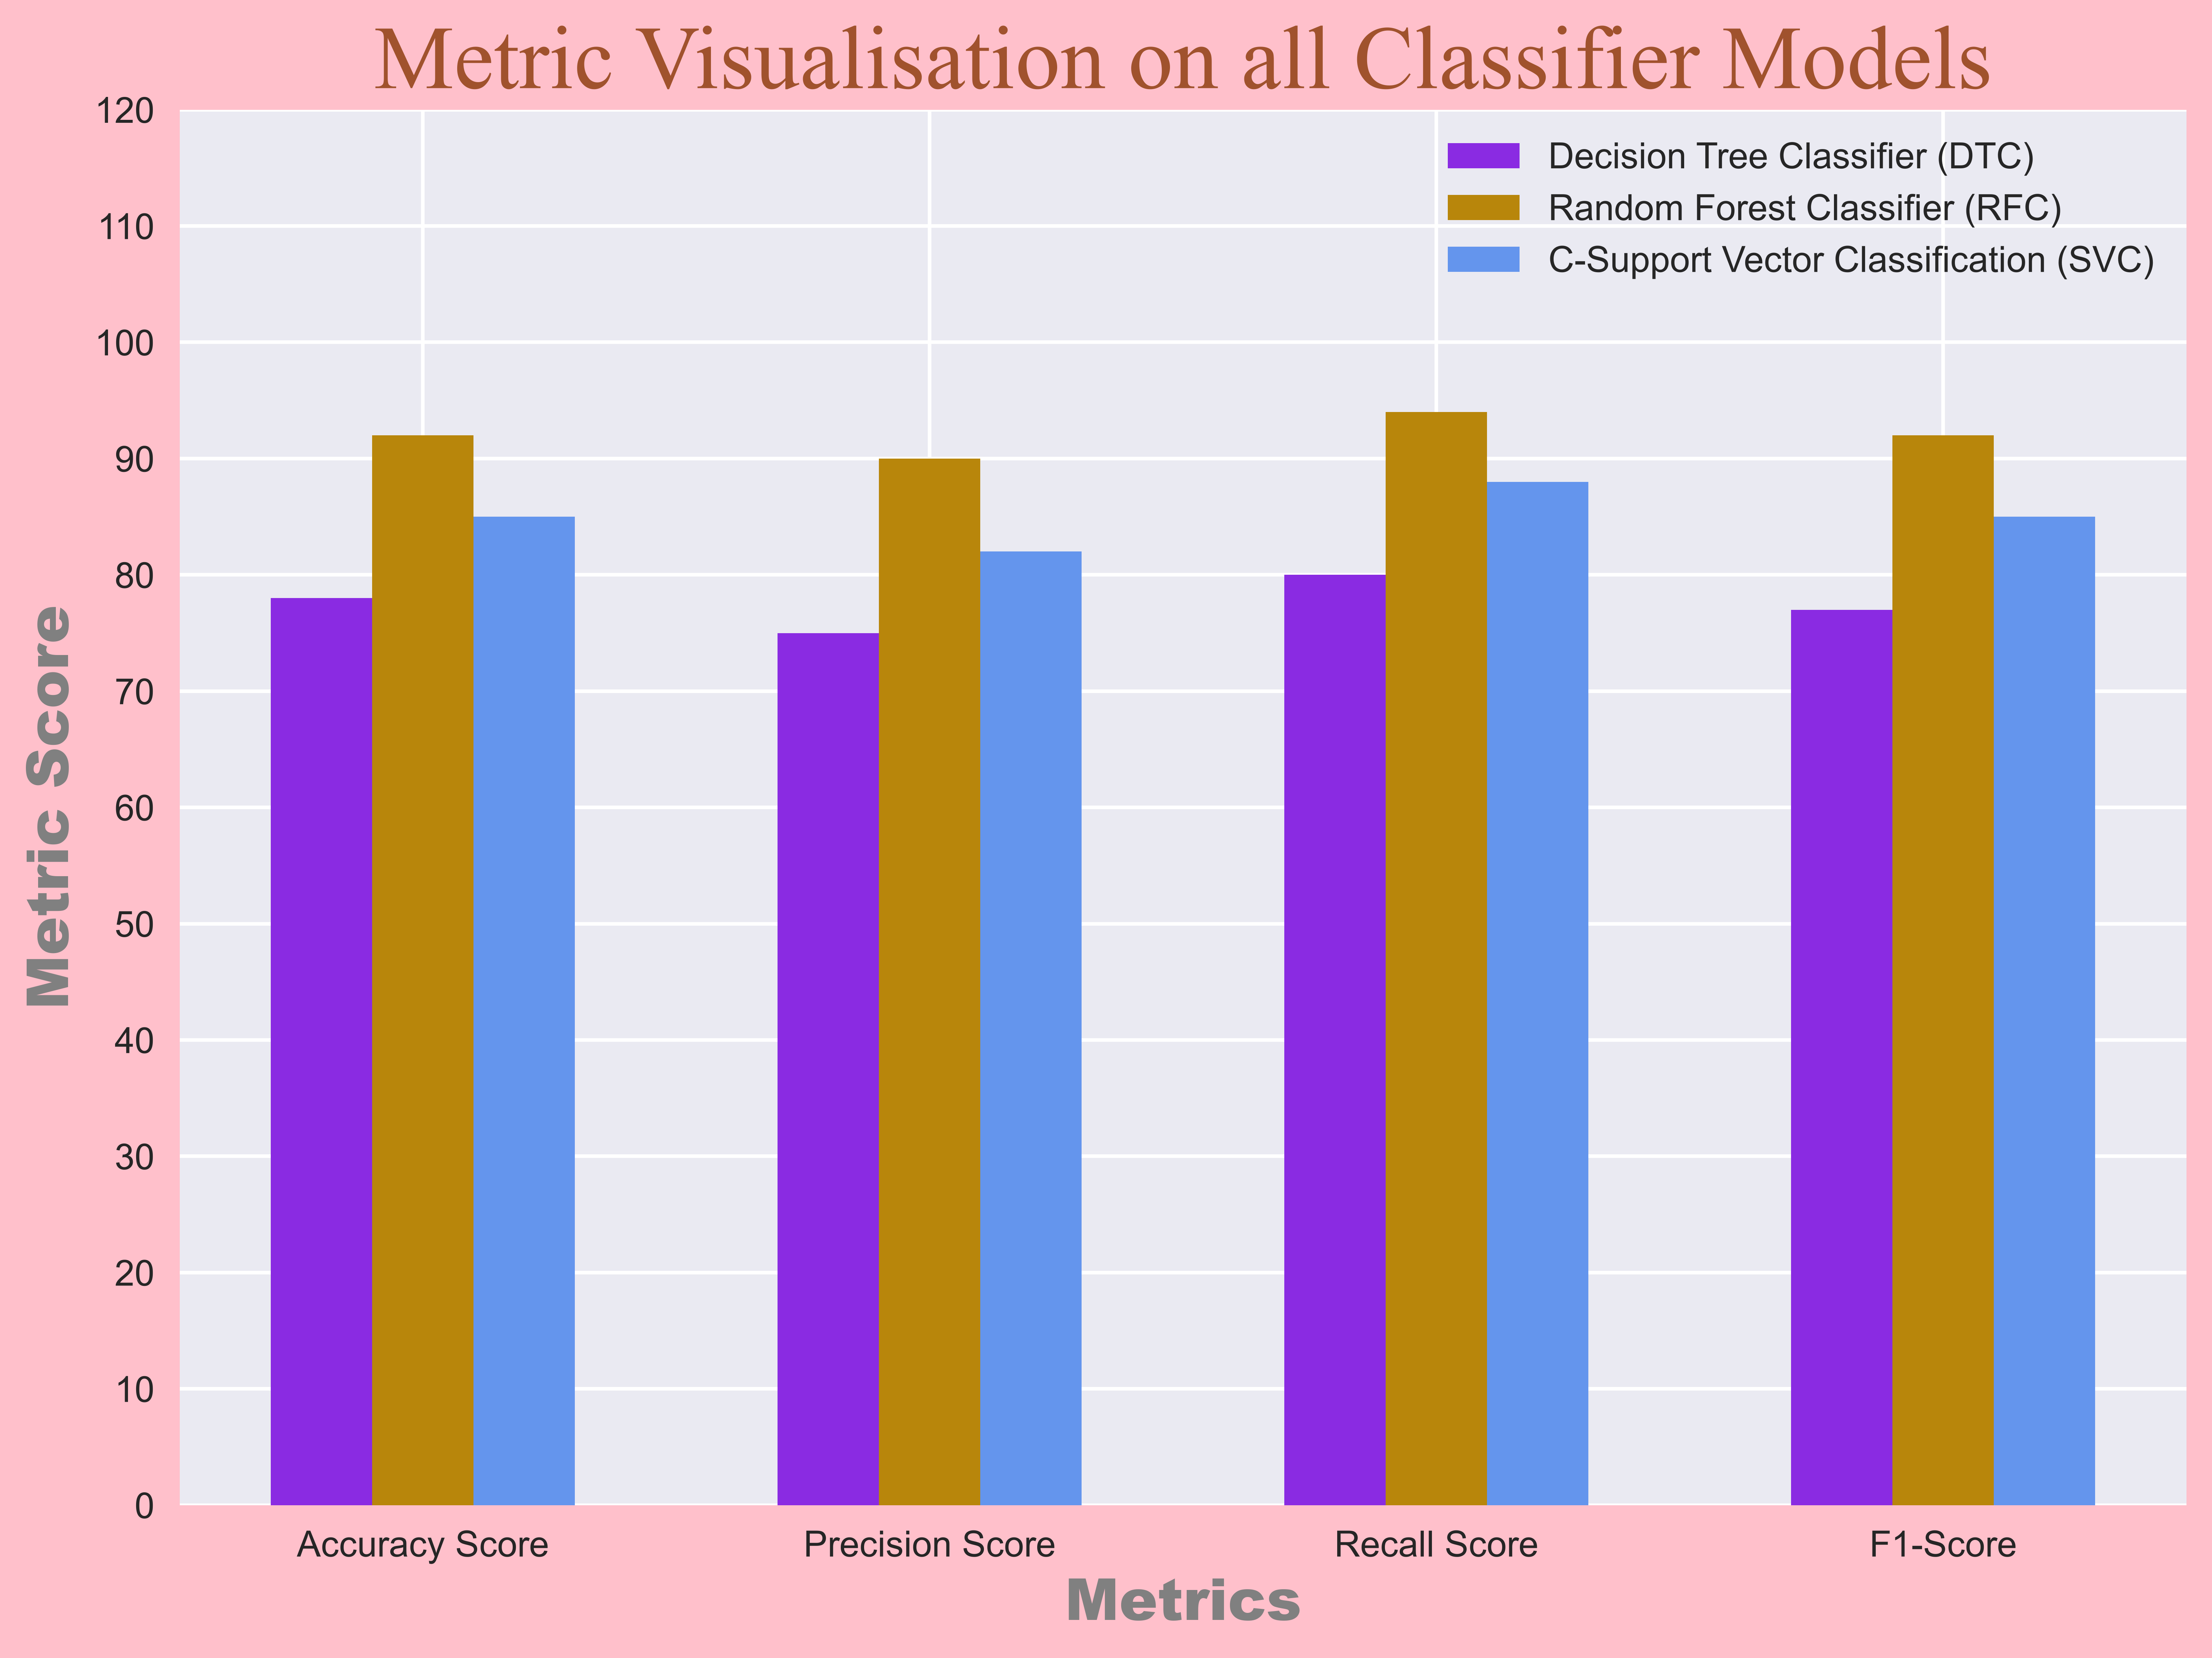

In [38]:
# Example: Define the missing score variables with sample values
# In practice, these would come from your actual model evaluation
svc_accuracy_score = 0.85
svc_precision_score = 0.82
svc_recall_score = 0.88
svc_f1_score = 0.85

dtc_accuracy_score = 0.78
dtc_precision_score = 0.75
dtc_recall_score = 0.80
dtc_f1_score = 0.77

rfc_accuracy_score = 0.92
rfc_precision_score = 0.90
rfc_recall_score = 0.94
rfc_f1_score = 0.92

# Convert to percentages and then to integers for plotting
svc_scores = (
    int(svc_accuracy_score * 100),  # Convert decimal to percentage
    int(svc_precision_score * 100),
    int(svc_recall_score * 100),
    int(svc_f1_score * 100)
)
dtc_scores = (
    int(dtc_accuracy_score * 100),  # Convert decimal to percentage
    int(dtc_precision_score * 100),
    int(dtc_recall_score * 100),
    int(dtc_f1_score * 100)
)
rfc_scores = (
    int(rfc_accuracy_score * 100),  # Convert decimal to percentage
    int(rfc_precision_score * 100),
    int(rfc_recall_score * 100),
    int(rfc_f1_score * 100)
)

# Import required libraries (add these if not already imported)
import matplotlib.pyplot as plt
from matplotlib import style
import numpy as np

x_grid = ["Accuracy Score", "Precision Score", "Recall Score", "F1-Score"]
y_grid = [value for value in range(0, 125, 10)]
xpos = np.arange(len(x_grid))
bar_width = .2

style.use("seaborn-v0_8")
plt.figure(figsize=(10, 7), dpi=700, facecolor="pink")
plt.title(
    "Metric Visualisation on all Classifier Models",
    fontdict={
        "fontname": "Times New Roman",
        "fontsize": 25
    },
    color="sienna"
)
plt.bar(xpos, dtc_scores, width=bar_width, color="blueviolet", label="Decision Tree Classifier (DTC)")
plt.bar(
    (xpos + 0.2), rfc_scores, width=bar_width, color="darkgoldenrod", label="Random Forest Classifier (RFC)"
)
plt.bar(
    (xpos + 0.4), svc_scores, width=bar_width, color="cornflowerblue",
    label="C-Support Vector Classification (SVC)"
)
plt.xlabel(
    "Metrics",
    fontdict={
        "fontname": "Arial Black",
        "fontsize": 16
    },
    color="grey"
)
plt.xticks((xpos + 0.2), x_grid)
plt.ylabel(
    "Metric Score",
    fontdict={
        "fontname": "Arial Black",
        "fontsize": 16
    },
    color="grey"
)
plt.yticks(y_grid)
plt.legend()
plt.show()

In [39]:
print("A 100 elements of Decision Tree Regressor Prediction:")
dtr_prediction[:100]

A 100 elements of Decision Tree Regressor Prediction:


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

In [40]:
print("A 100 elements of Random Forest Regressor Prediction:")
rfr_prediction[:100]

A 100 elements of Random Forest Regressor Prediction:


array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.65, 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.1 , 0.  , 0.06, 0.  , 0.  ,
       1.  , 0.  , 0.  , 1.  , 0.  , 0.  , 0.07, 1.  , 0.96, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.91, 0.  , 0.  , 0.  , 0.  , 0.15, 0.  ,
       0.  , 0.  , 0.  , 0.03, 0.  , 0.2 , 0.  , 0.  , 0.  , 0.02, 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.92,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.11, 0.  , 0.  , 1.  ,
       0.  , 0.27, 0.  , 0.02, 0.  , 0.  , 0.12, 0.  , 0.  , 0.  , 0.26,
       0.16, 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.01, 0.  , 0.  , 1.  ,
       0.  ])

In [41]:
print("A 100 elements of Epsilon-Support Vector Regression Prediction:")
svr_prediction[:100]

A 100 elements of Epsilon-Support Vector Regression Prediction:


array([ 0.11698349, -0.02039512,  0.17198534,  0.10742801, -0.00283561,
        0.0459008 ,  0.07449401,  0.0999933 ,  0.12655346,  0.55677534,
       -0.01312231,  0.14835559,  0.05121726,  0.09556396,  0.02100116,
        0.10023506,  0.1358278 ,  0.21631399,  0.20376893,  0.11377707,
        0.28033469,  0.03756937,  0.74534719,  0.10463684,  0.07481223,
        0.89997954, -0.01309654,  0.07348326,  0.12691581,  0.82628988,
        0.14128666,  0.16681803,  0.12558209,  0.11649612,  0.13078816,
        0.05246356,  0.02985088,  0.70324987,  0.04836089,  0.01981598,
        0.1147567 ,  0.09744418,  0.08736534, -0.00405193,  0.04894533,
        0.21018915,  0.10469484,  0.34824025,  0.07183981,  0.11054115,
        0.17366771,  0.12553002,  0.09270879,  0.18536604,  0.10005807,
        0.09998461,  0.06744237,  0.15169768,  0.05755445,  0.07241833,
        0.10600979,  0.08723128,  0.09204115,  0.87036009,  0.05981099,
        0.91544802,  0.07516604, -0.01489905,  0.11223997,  0.11

In [44]:
print("A 100 elements of Decision Tree Classifier Prediction:")
dtc_prediction[:100]

A 100 elements of Decision Tree Classifier Prediction:


array([1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1])

In [48]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

# Create sample data (replace this with your actual dataset)
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

# Make predictions - this creates the rfc_prediction variable
rfc_prediction = rfc.predict(X_test)

# Now you can display the first 100 elements
print("A 100 elements of Random Forest Classifier Prediction:")
rfc_prediction[:100]

A 100 elements of Random Forest Classifier Prediction:


array([1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0])

In [49]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

# Create sample data (replace this with your actual dataset)
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the Support Vector Classifier
svc_model = SVC(kernel='rbf', random_state=42)  # You can adjust kernel and other parameters
svc_model.fit(X_train, y_train)

# Make predictions on the test set
svc_prediction = svc_model.predict(X_test)  # This creates the missing variable

# Now you can display the first 100 elements
print("A 100 elements of C-Support Vector Classification Prediction:")
svc_prediction[:100]

A 100 elements of C-Support Vector Classification Prediction:


array([1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0])